## Comparison of model to actual label and feature impoortance
A data-driven statistical model for predicting the critical temperature of a superconductor, K. Hamidieh. 2018, Computational materials science, https://doi.org/10.1016/j.commatsci.2018.07.052

The data have been reduced to 3% in "train_small.csv". There are 81 features.

Random Forest -> MSE: 256.758, R^2: 0.757


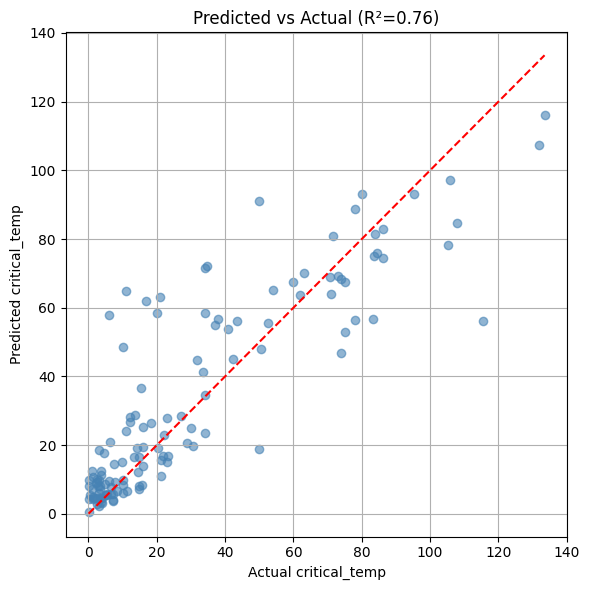


Top 10 important features:
range_ThermalConductivity: 0.20953
wtd_gmean_Valence: 0.17938
wtd_mean_Valence: 0.15724
wtd_std_ThermalConductivity: 0.06295
wtd_gmean_ThermalConductivity: 0.03812
std_atomic_mass: 0.02386
wtd_entropy_FusionHeat: 0.02029
wtd_std_ElectronAffinity: 0.01541
wtd_entropy_Density: 0.01237
entropy_atomic_radius: 0.01140
wtd_range_ElectronAffinity: 0.01103
wtd_entropy_ElectronAffinity: 0.01089
std_ElectronAffinity: 0.01081
wtd_entropy_fie: 0.01075
mean_ThermalConductivity: 0.01025


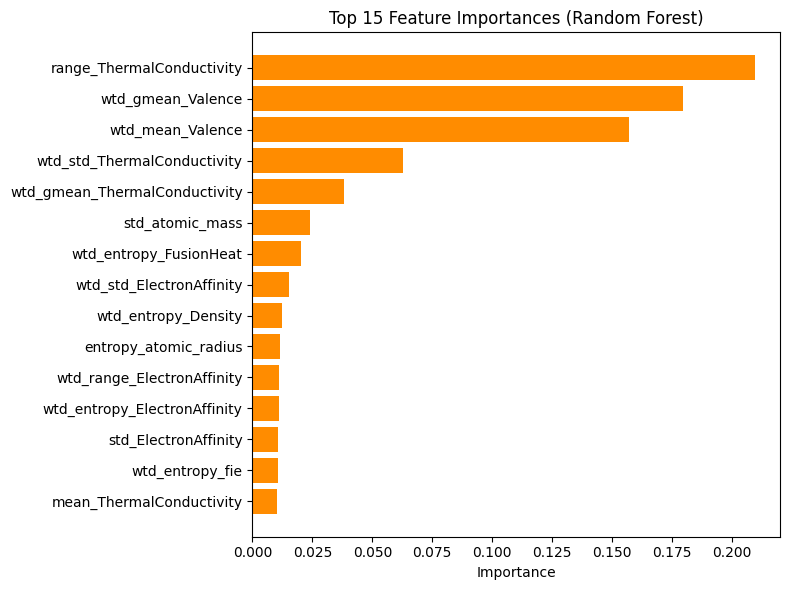

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
data = pd.read_csv('train_small.csv')  # Ensure train_small.csv is in your working directory

# 2. Split features and label
features = data.iloc[:, :-1]  # All columns except last
label = data.iloc[:, -1]      # Last column (critical_temp)


# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)

# 4. Train RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Random Forest -> MSE: {mse:.3f}, R^2: {r2:.3f}')

# 7. Plot Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title(f'Predicted vs Actual (R²={r2:.2f})')
plt.xlabel('Actual critical_temp')
plt.ylabel('Predicted critical_temp')
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Feature Importance, sort them
importances = model.feature_importances_
top_idx = np.argsort(importances)[::-1]
top_features = [features.columns[i] for i in top_idx]
top_importances = importances[top_idx]

# Print top 10 important features
print("\nTop 10 important features:")
for i in range(15):
    print(f'{top_features[i]}: {top_importances[i]:.5f}')


# Plot top 15 feature importances
plt.figure(figsize=(8, 6))
plt.barh(top_features[:15][::-1], top_importances[:15][::-1], color='darkorange')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


